#RIT Opportunity Wise Data analysis

##TASK-1 Understanding the Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print("libraries imported successfully")

libraries imported successfully


In [1]:
df = pd.read_csv("/content/RIT+Opportunity+Wise+Data+-+Sheet1.csv")
df.head(20)
print('file import successfully')

NameError: name 'pd' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.shape

(3950, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Learner SignUp DateTime  3950 non-null   object 
 1   Opportunity Id           3950 non-null   object 
 2   Opportunity Name         3950 non-null   object 
 3   Opportunity Category     3950 non-null   object 
 4   Opportunity End Date     3950 non-null   object 
 5   First Name               3950 non-null   object 
 6   Date of Birth            3950 non-null   object 
 7   Gender                   3950 non-null   object 
 8   Country                  3950 non-null   object 
 9   Institution Name         3947 non-null   object 
 10  Current/Intended Major   3946 non-null   object 
 11  Entry created at         3949 non-null   object 
 12  Status Description       3949 non-null   object 
 13  Status Code              3949 non-null   float64
 14  Apply Date              

In [ ]:
df.dtypes

,0
Learner SignUp DateTime,object
Opportunity Id,object
Opportunity Name,object
Opportunity Category,object
Opportunity End Date,object
First Name,object
Date of Birth,object
Gender,object
Country,object
Institution Name,object


In [ ]:
df['Status Code'].value_counts()

,count
Status Code,
1030.0,1459
1070.0,1330
1080.0,654
1050.0,376
1040.0,61
1110.0,53
1010.0,9
1120.0,7


In [ ]:
df['Opportunity Category'].value_counts()

,count
Opportunity Category,
Internship,2523
Course,1423
Competition,4


In [ ]:
df.isnull().sum()

,0
Learner SignUp DateTime,0
Opportunity Id,0
Opportunity Name,0
Opportunity Category,0
Opportunity End Date,0
First Name,0
Date of Birth,0
Gender,0
Country,0
Institution Name,3


In [ ]:
(df.isnull().sum()/len(df))*100

,0
Learner SignUp DateTime,0.000000
Opportunity Id,0.000000
Opportunity Name,0.000000
Opportunity Category,0.000000
Opportunity End Date,0.000000
First Name,0.000000
Date of Birth,0.000000
Gender,0.000000
Country,0.000000
Institution Name,0.075949


In [ ]:
df['Institution Name'] = df['Institution Name'].fillna('Unknown')

In [ ]:
df['Current/Intended Major'] = (df['Current/Intended Major'].fillna('Unknown')
)

In [ ]:
df.groupby('Opportunity Category')['Opportunity Start Date'].apply(lambda x: x.isnull().mean()*100)

,Opportunity Start Date
Opportunity Category,
Competition,100.000000
Course,4.356992
Internship,58.224336


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Learner SignUp DateTime  3950 non-null   object 
 1   Opportunity Id           3950 non-null   object 
 2   Opportunity Name         3950 non-null   object 
 3   Opportunity Category     3950 non-null   object 
 4   Opportunity End Date     3950 non-null   object 
 5   First Name               3950 non-null   object 
 6   Date of Birth            3950 non-null   object 
 7   Gender                   3950 non-null   object 
 8   Country                  3950 non-null   object 
 9   Institution Name         3950 non-null   object 
 10  Current/Intended Major   3950 non-null   object 
 11  Entry created at         3949 non-null   object 
 12  Status Description       3949 non-null   object 
 13  Status Code              3949 non-null   float64
 14  Apply Date              

In [ ]:
datecols = ['Learner SignUp DateTime', 'Opportunity End Date', 'Date of Birth',
            'Entry created at', 'Apply Date', 'Opportunity Start Date']

for col in datecols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Learner SignUp DateTime  3737 non-null   datetime64[ns]
 1   Opportunity Id           3950 non-null   object        
 2   Opportunity Name         3950 non-null   object        
 3   Opportunity Category     3950 non-null   object        
 4   Opportunity End Date     1423 non-null   datetime64[ns]
 5   First Name               3950 non-null   object        
 6   Date of Birth            3950 non-null   datetime64[ns]
 7   Gender                   3950 non-null   object        
 8   Country                  3950 non-null   object        
 9   Institution Name         3950 non-null   object        
 10  Current/Intended Major   3950 non-null   object        
 11  Entry created at         3949 non-null   datetime64[ns]
 12  Status Description       3949 non-

##Task-2 Data Dictionary

In [ ]:
df['Opportunity Category'].value_counts()

,count
Opportunity Category,
Internship,2523
Course,1423
Competition,4


In [ ]:
df['Status Description'].value_counts()

,count
Status Description,
Rejected,1459
Team Allocated,1330
Started,654
Dropped Out,376
Waitlisted,61
Withdraw,53
Applied,9
Rewards Award,7


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,2291
Female,1650
Don't want to specify,8
Other,1


In [ ]:
status_by_cat = pd.crosstab(
    df['Opportunity Category'],
    df['Status Description']
)

status_by_cat

Status Description,Applied,Dropped Out,Rejected,Rewards Award,Started,Team Allocated,Waitlisted,Withdraw
Opportunity Category,,,,,,,,
Competition,0,4,0,0,0,0,0,0
Course,0,0,0,7,654,682,61,19
Internship,9,372,1459,0,0,648,0,34


In [ ]:
rejection_rate = (df[df['Status Description']== "Rejected"].groupby('Opportunity Category').size()/df.groupby('Opportunity Category').size())*100
print(rejection_rate)

Opportunity Category
Competition          NaN
Course               NaN
Internship     57.827983
dtype: float64


In [ ]:
df['Institution Name'].value_counts()

,count
Institution Name,
Saint Louis University,1112
saint louis university,356
Saint Louis university,101
Saint louis university,97
Illinois Institute of Technology,60
...,...
Gitam University,1
University of bridgeport,1
Delta state University Abraka,1


In [ ]:
schools = df['Institution Name'].unique()
schools

array(['Nwihs', 'SAINT LOUIS', 'Illinois Institute of Technology', ...,
       'BABCOCK', 'KIET GROUP OF INSTITUSIONS', 'University o'],
      dtype=object)

In [ ]:
df['Institution Name'] = (
    df['Institution Name'].str.strip() .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
print(df.info())


Dataset Shape: (3950, 16)

Column Names:
['Learner SignUp DateTime', 'Opportunity Id', 'Opportunity Name', 'Opportunity Category', 'Opportunity End Date', 'First Name', 'Date of Birth', 'Gender', 'Country', 'Institution Name', 'Current/Intended Major', 'Entry created at', 'Status Description', 'Status Code', 'Apply Date', 'Opportunity Start Date']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3950 entries, 0 to 3949
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Learner SignUp DateTime  3737 non-null   datetime64[ns]
 1   Opportunity Id           3950 non-null   object        
 2   Opportunity Name         3950 non-null   object        
 3   Opportunity Category     3950 non-null   object        
 4   Opportunity End Date     1423 non-null   datetime64[ns]
 5   First Name               3950 non-null   object        
 6   Date of Birth            3950 non-n

##Task-3 Initial Data Preparation

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)



Missing Values:
Learner SignUp DateTime     213
Opportunity Id                0
Opportunity Name              0
Opportunity Category          0
Opportunity End Date       2527
First Name                    0
Date of Birth                 0
Gender                        0
Country                       0
Institution Name              0
Current/Intended Major        0
Entry created at              1
Status Description            1
Status Code                   1
Apply Date                  142
Opportunity Start Date     1818
dtype: int64


/tmp/ipykernel_3644/1554804526.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3644/3788061211.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
duplicates = df.duplicated().sum()
print("\nDuplicate Records Found:", duplicates)

df.drop_duplicates(inplace=True)


Duplicate Records Found: 0


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
for col in categorical_cols:
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
        else:
            col_norm = col.strip().lower().replace(' ', '_').replace('/', '_')
            if col_norm in df.columns:
                df[col_norm] = df[col_norm].astype(str).str.strip()
            else:
                print(f"Warning: column '{col}' not found (tried '{col_norm}')")

In [ ]:
print("\nData Types:")
print(df.dtypes)



Data Types:
learner_signup_datetime    datetime64[ns]
opportunity_id                     object
opportunity_name                   object
opportunity_category               object
opportunity_end_date       datetime64[ns]
first_name                         object
date_of_birth              datetime64[ns]
gender                             object
country                            object
institution_name                   object
current/intended_major             object
entry_created_at           datetime64[ns]
status_description                 object
status_code                       float64
apply_date                 datetime64[ns]
opportunity_start_date     datetime64[ns]
dtype: object


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [ ]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nFinal Dataset Shape:", df.shape)

df.to_excel("RIT_Cleaned_Dataset.xlsx", index=False)

print("\nCleaned dataset saved successfully as 'RIT_Cleaned_Dataset.xlsx'")


Missing Values After Cleaning:
learner_signup_datetime     213
opportunity_id                0
opportunity_name              0
opportunity_category          0
opportunity_end_date       2527
first_name                    0
date_of_birth                 0
gender                        0
country                       0
institution_name              0
current/intended_major        0
entry_created_at              1
status_description            0
status_code                   0
apply_date                  142
opportunity_start_date     1818
dtype: int64

Final Dataset Shape: (3950, 16)

Cleaned dataset saved successfully as 'RIT_Cleaned_Dataset.xlsx'


## Task 4: Descriptive Statistics and Participation Analysis

In [ ]:
df.to_excel("RIT_Cleaned_Dataset.xlsx", index=False)
print("Successfully Clean_Dataset imported")

Successfully Clean_Dataset imported


In [ ]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 3950
Columns: 16


In [ ]:
Opp_count=df['opportunity_category'].value_counts()
print(Opp_count)

opportunity_category
Internship     2523
Course         1423
Competition       4
Name: count, dtype: int64


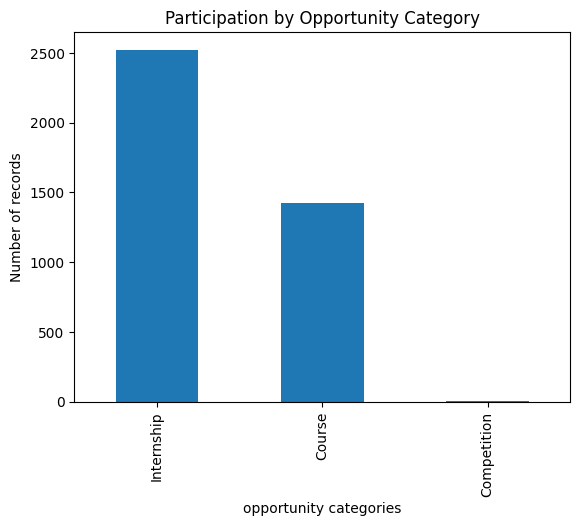

In [ ]:
Opp_count.plot(kind='bar')
plt.title("Participation by Opportunity Category")
plt.xlabel("opportunity categories")
plt.ylabel("Number of records")

plt.show()

In [ ]:
States_count=df['status_description'].value_counts()
print(States_count)


status_description
Rejected          1460
Team Allocated    1330
Started            654
Dropped Out        376
Waitlisted          61
Withdraw            53
Applied              9
Rewards Award        7
Name: count, dtype: int64


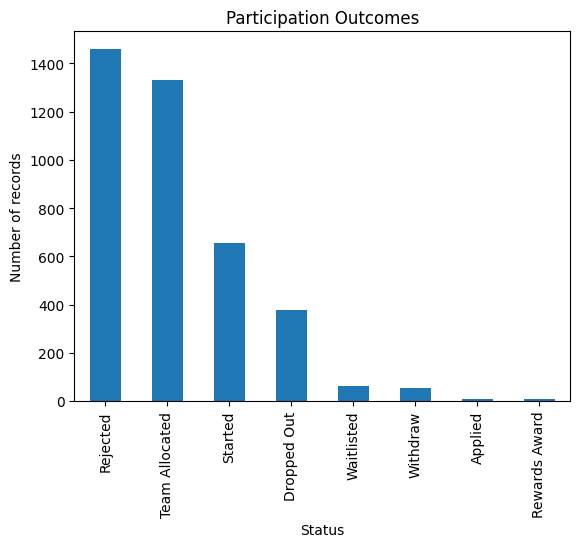

In [ ]:
States_count.plot(kind='bar')
plt.title("Participation Outcomes")
plt.xlabel("Status")
plt.ylabel("Number of records")
plt.show()

In [ ]:
if 'age' not in df.columns:
    today = pd.Timestamp('today')
    df['age'] = (today - df['date_of_birth']).dt.days // 365

print(df['age'].describe())



count    3950.000000
mean       26.218734
std         4.461166
min         7.000000
25%        24.000000
50%        26.000000
75%        28.000000
max        58.000000
Name: age, dtype: float64


In [ ]:
bins = [0, 20, 25, 30, 35, 40, 100]
labels = ['18-20','21-25','26-30','31-35','36-40','41+']
df['Age Group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
Age_count = df['Age Group'].value_counts().sort_index()
Age_count

,count
Age Group,
18-20,199
21-25,1744
26-30,1571
31-35,261
36-40,114
41+,61


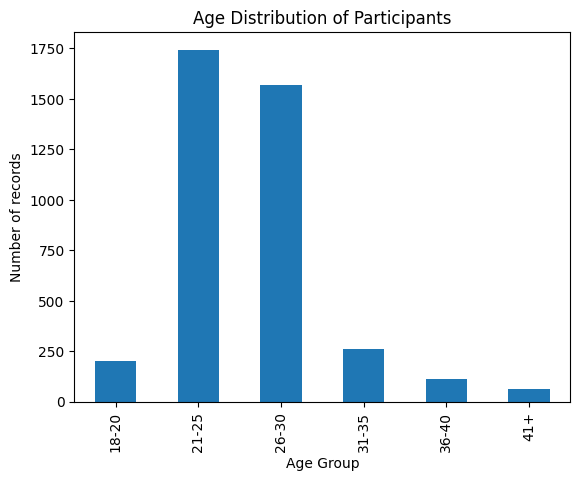

In [ ]:
Age_count.plot(kind='bar')

plt.title("Age Distribution of Participants")
plt.xlabel("Age Group")
plt.ylabel("Number of records")
plt.show()

In [ ]:
Country_count=df['country'].value_counts().head(10)
print(Country_count)

country
United States    1710
India            1259
Nigeria           384
Ghana             152
Pakistan          151
Bangladesh         38
Egypt              34
Kenya              23
Ethiopia           19
Nepal              14
Name: count, dtype: int64


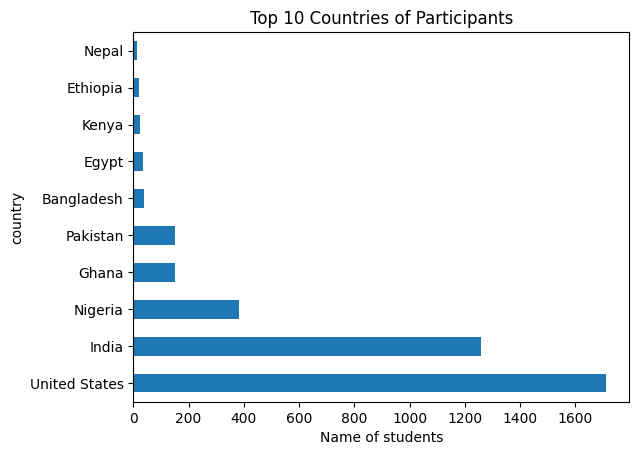

In [ ]:
Country_count.plot(kind='barh')

plt.title("Top 10 Countries of Participants")
plt.xlabel("Name of students")

plt.show()

In [ ]:
gender_col = next((c for c in df.columns if c.lower() == 'gender'), None)
if gender_col is not None:
    gender_counts = df[gender_col].value_counts()
else:
    gender_counts = pd.Series(dtype=int)
    print("Warning: 'gender' column not found")
gender_counts

,count
gender,
Male,2291
Female,1650
Don't want to specify,8
Other,1


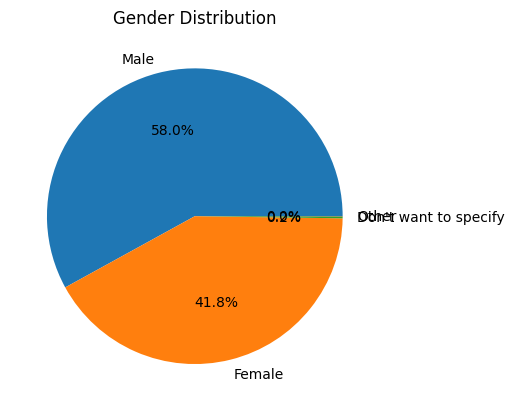

In [ ]:
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Gender Distribution')
plt.show()